# Transient & MCMC I

Let's study transient fenomena with the use of MCMC and Metropolis-Hastings algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [2]:
data = np.load("../Solutions/transient.npy")
time, flux, error = data.T

In [3]:
# Define the model
def Model(t, b, A, alpha, t0):
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

# Define the log-likelihood
def logLikelihood(theta, t, flux, error):
    b, A, alpha, t0 = theta
    model = Model(t, b, A, alpha, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL 

# Define the log-prior
def logPrior(theta):
    b, A, alpha, t0 = theta
    if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
        return -np.log(alpha) 
    return -np.inf 

# Define the log-posterior
def logPosterior(theta, t, flux, error):
    logP = logPrior(theta)
    if not np.isfinite(logP):
        return -np.inf
    return logP + logLikelihood(theta, t, flux, error)

In [4]:
ndim = 4
nwalkers = 50

We need to take into account a thermalization time, plus the autocorralation. We run a smal test to set the burn and the thinning for the chain.

  0%|          | 0/2000 [00:00<?, ?it/s]/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_55914/3384519921.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 2000/2000 [00:02<00:00, 881.30it/s]


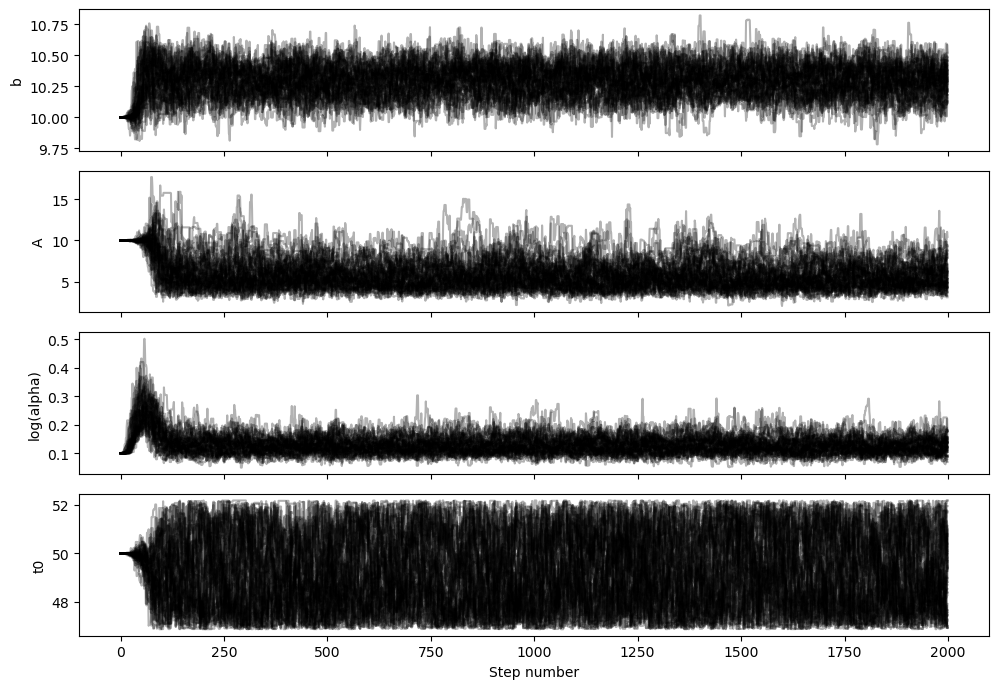

In [5]:
burn = 2000
try_sempler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))
initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)
try_sempler.run_mcmc(initial_pos, burn, progress=True)

traces = try_sempler.get_chain()
labels = ["b", "A", "log(alpha)", "t0"]
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(traces[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()

Let's conclude that we need at least 100 steps to burn the chain.

In [6]:
tau = try_sempler.get_autocorr_time()
print(tau)
thin = int(np.max(tau) + 1)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [47.4460649  67.88372133 52.0183342  55.02719504]

In [7]:
# Run the sampler for a longer time to get better estimates, considering the autocorrelation time
burn = 500
nsteps = 10000

sempler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))

initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)

sempler.run_mcmc(initial_pos, nsteps, progress=True)

  0%|          | 0/10000 [00:00<?, ?it/s]/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_55914/3384519921.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 10000/10000 [00:10<00:00, 911.50it/s]


State([[10.16190418  9.22149245  0.16885924 48.06214607]
 [10.42566501  3.46783226  0.14060063 51.39470446]
 [10.50639499  4.43044159  0.10113398 47.36683664]
 [10.33575752  5.0924085   0.09699167 49.16949217]
 [10.1928739   4.50065892  0.09086549 49.19516197]
 [10.57380905  8.12482707  0.19367093 48.15836017]
 [10.3212989   3.30239965  0.11635192 52.15872183]
 [10.17101909  4.52825873  0.06872114 47.65095083]
 [10.25186504  5.68207473  0.14132634 49.4824072 ]
 [10.19758673  5.85558046  0.11419748 48.18081733]
 [10.18176661  3.71835221  0.08933414 50.72192313]
 [10.21848988  5.26474758  0.0987021  48.22841037]
 [10.32095824  5.56325156  0.12888213 50.34467917]
 [10.39964065  2.71182174  0.09691603 50.73792972]
 [10.24914991  3.67945443  0.09580589 51.89858593]
 [10.31398824  7.37438792  0.13443978 47.9865569 ]
 [10.2476266   5.86838491  0.12065826 49.16744763]
 [10.23029802  7.4407141   0.14911041 49.04142695]
 [10.47882911  6.90134114  0.15506609 48.69260478]
 [10.3458733   5.96806477

In [8]:
tau = sempler.get_autocorr_time()
print(tau)
thin = int(np.max(tau) + 1)

[55.23642921 74.6590371  58.66695567 69.67148608]


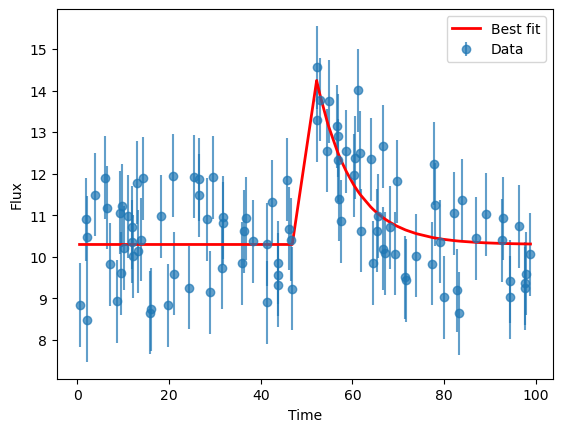

In [9]:
samples = sempler.get_chain(discard=burn, thin=thin, flat=True)

best_params = samples.mean(axis=0)

plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
model_flux = Model(time, *best_params)
plt.plot(time, model_flux, 'r-', label='Best fit', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

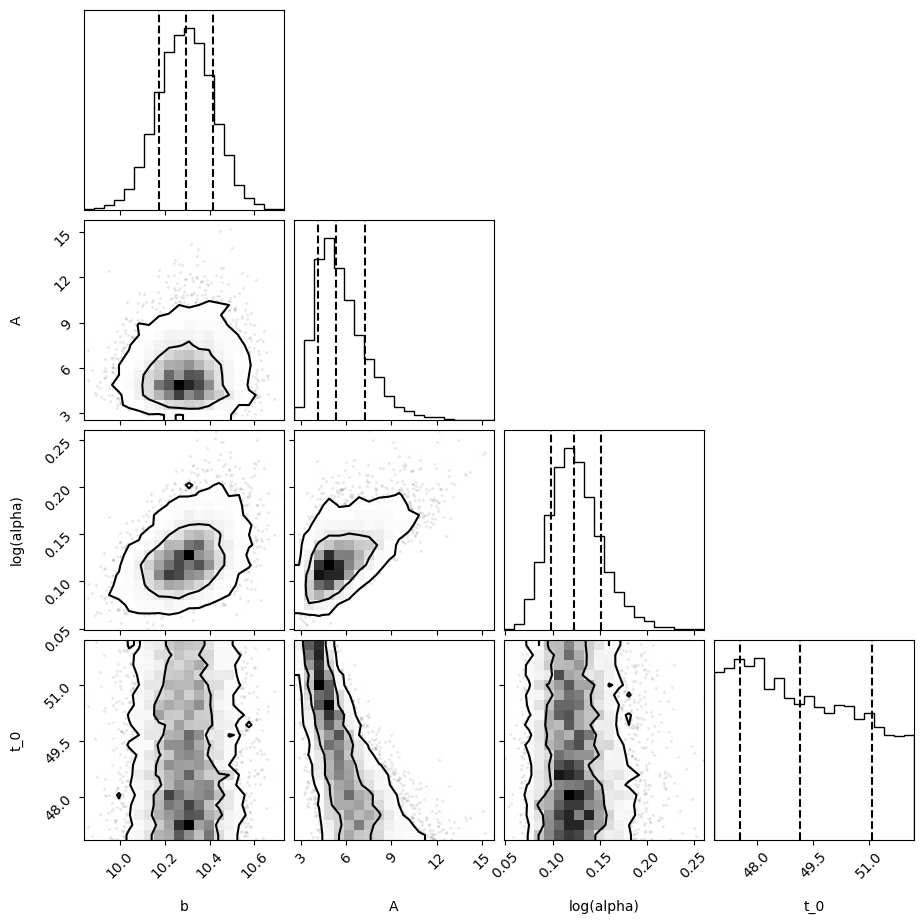

In [18]:
import corner as corner

labels = ["b", "A", "log(alpha)", "t_0"]

fig = corner.corner(
    samples, 
    labels=labels, 
    levels=[0.68, 0.95],
    quantiles=[0.16, 0.5, 0.84]
)
plt.show()

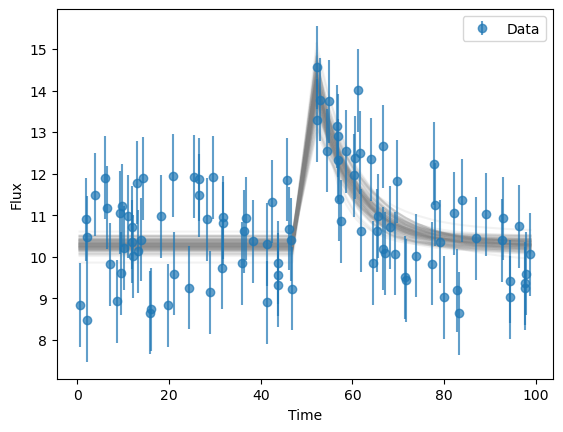

In [19]:
random_samples = samples[np.random.choice(samples.shape[0], size=100, replace=False)]

for i in range(len(random_samples)):
    y = Model(time, *random_samples[i])
    plt.plot(time, y, color='gray', alpha=0.1)
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()


In [20]:
median_params = np.median(samples, axis=0)
percentiles_params = np.percentile(samples, [5, 95], axis=0)

for i, param in enumerate(labels):
    print(f"{param}: {median_params[i]:.3f} (+{percentiles_params[1, i] - median_params[i]:.3f}, -{median_params[i] - percentiles_params[0, i]:.3f})")

b: 10.294 (+0.196, -0.204)
A: 5.350 (+3.456, -1.749)
log(alpha): 0.122 (+0.053, -0.038)
t_0: 49.143 (+2.682, -2.060)


We can check also the walker bheaviuor.

Mean acceptance fraction: 0.531236
Acceptance fraction (per walker, first 10): [0.5287 0.5428 0.5309 0.5162 0.5315 0.5225 0.5285 0.5372 0.5424 0.5188]


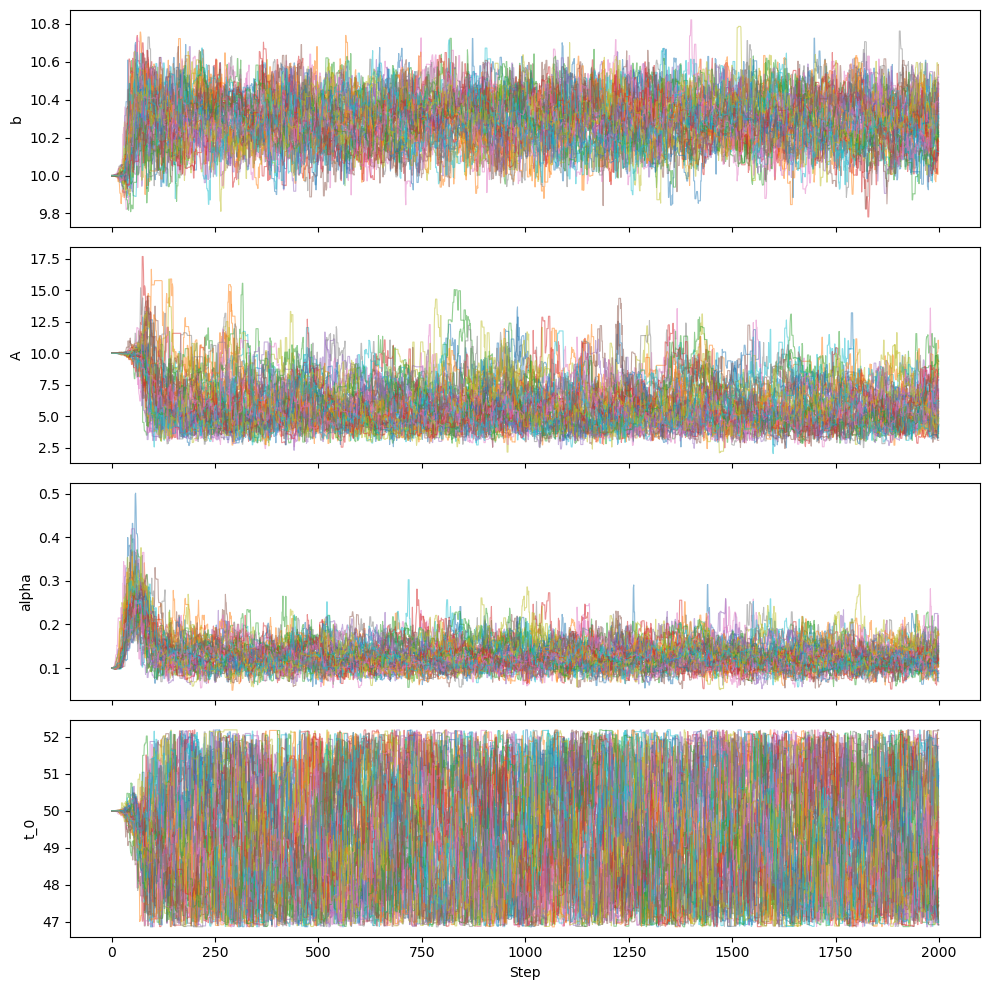

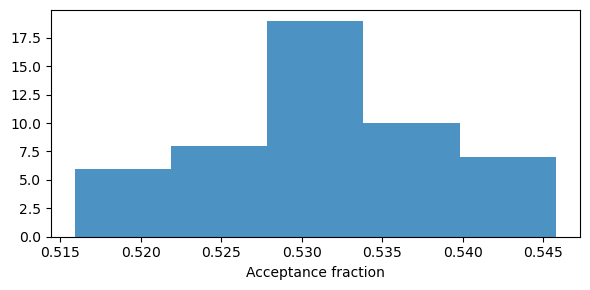

In [13]:
acc = getattr(sempler, "acceptance_fraction", None)
if acc is not None:
    print("Mean acceptance fraction:", acc.mean())
    print("Acceptance fraction (per walker, first 10):", acc[:10])

fig, axes = plt.subplots(ndim, 1, figsize=(10, 2.5 * ndim), sharex=True)
for j in range(ndim):
    ax = axes[j]
    ax.plot(traces[:, :, j], lw=0.8, alpha=0.5)
    ax.set_ylabel(labels[j])
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

if acc is not None:
    plt.figure(figsize=(6,3))
    plt.hist(acc, bins='scott', alpha=0.8)
    plt.xlabel("Acceptance fraction")
    plt.tight_layout()
    plt.show()

### Savage-Dickey ratio

Use to check that indeed we have a signal over noise.

In [14]:
from sklearn.neighbors import KernelDensity

def kde(samples, bandwith, kernel):
    kde = KernelDensity(bandwidth=bandwith, kernel=kernel)
    kde.fit(samples[:, None])
    return kde

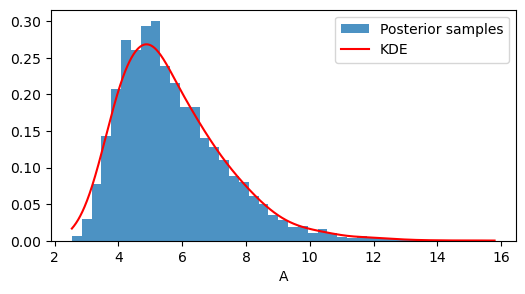

In [15]:
posterior_samples = samples[:, 1]
posterior_kde = kde(posterior_samples, bandwith=0.5, kernel='gaussian')

plt.figure(figsize=(6,3))
plt.hist(posterior_samples, bins='scott', density=True, alpha=0.8, label='Posterior samples')
x = np.linspace(posterior_samples.min(), posterior_samples.max(), 1000)[:, None]
log_dens = posterior_kde.score_samples(x)
plt.plot(x, np.exp(log_dens), 'r-', label='KDE')
plt.xlabel("A")
plt.legend()

In [16]:
A_ref = 0.0
posterior_density = np.exp(posterior_kde.score_samples([[A_ref]]))[0]
prior_density = 1 / 50
bayes_factor = prior_density / posterior_density

print(f'Posterior density at A={A_ref}: {posterior_density:.3e}')
print(f'Prior density at A={A_ref}: {prior_density:.3e}')
print(f'Approximate Savage-Dickey Bayes factor: {bayes_factor:.3f}')

Posterior density at A=0.0: 1.104e-09
Prior density at A=0.0: 2.000e-02
Approximate Savage-Dickey Bayes factor: 18113989.836


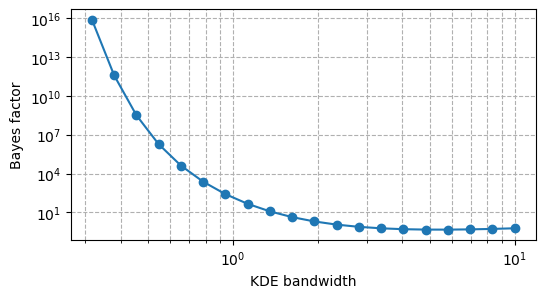

In [17]:
bandwith = np.logspace(-0.5, 1, 20)
bayesian_factors = []

for bw in bandwith:
    posterior_kde = kde(posterior_samples, bandwith=bw, kernel='gaussian')
    posterior_density = np.exp(posterior_kde.score_samples([[A_ref]]))[0]
    bayes_factor = prior_density / posterior_density
    bayesian_factors.append(bayes_factor)

plt.figure(figsize=(6,3))
plt.loglog(bandwith, bayesian_factors, marker='o')
plt.xlabel('KDE bandwidth')
plt.ylabel('Bayes factor')
plt.grid(True, which="both", ls="--")
plt.show()

We can confirm what we qualitatively expected: we have identified a clear signal over noise. However, we shouldn't put much confidence in the precise value of the Bayes factor for this claim, since it is sensitive to the KDE bandwidth choice in the tail region.